## **2. Yield Curve Modeling**

#### a. Pick government securities from a country. The country selected should be one of the countries from your group so that you can fit a Nelson-Siegel model.

**Yield Curve Construction for France** : To constuct Constant Maturity Treasury (CMT) yield curve data from France has been used.

The CMT yield curve similar to U.S. Treasury yields are calculated on daily basis and the dataset is accessable here: (Banque de France, n.d., https://webstat.banque-france.fr/en/catalogue/fm/). For the purpose of this exercise the 45 series of data has been downloaded, cleaned and reshaped.

In [ ]:
#| echo: false
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [ ]:
# data loading and cleaning
# Load the file
df = pd.read_csv("WEBSTAT-observations-2025-07-01T20_42_57.642+02_00.csv")
# strip column names of whitespace if any
df.columns = df.columns.str.strip()
df = df[df['title_en'].str.contains("constant maturity rate", case=False, na=False)]
df = df[["time_period", "title_en", "obs_value"]]
# Pivot so each maturity becomes a column
df_wide = df.pivot_table(
    index='time_period',
    columns='title_en',
    values='obs_value',
    # aggfunc='mean'  # can done in case of duplicates, particurly with this dataset not required
)

# rename columns to cleaner format
df_wide.columns = df_wide.columns.str.replace("Constant maturity rate ", "").str.title()
df_wide.columns = df_wide.columns.str.replace("Years", "Year").str.title()

# Convert time_period to datetime
df_wide.index = pd.to_datetime(df_wide.index, format='ISO8601')

# Sort by date
df_wide = df_wide.sort_index()
df_wide.columns.name = None
df_wide.index.name = None

# Preview
df_wide.head()

,1 Year,10 Year,15 Year,2 Year,20 Year,25 Year,3 Year,30 Year,5 Year,7 Year
2004-11-01,NaN,3.8525,NaN,2.434,NaN,NaN,NaN,NaN,3.12,NaN
2004-11-03,2.27,3.9700,4.20,2.490,4.44,NaN,2.76,NaN,3.23,3.59
2004-11-04,2.25,3.9300,4.17,2.450,4.40,NaN,2.71,NaN,3.18,3.54
2004-11-05,2.26,3.9100,4.15,2.450,4.38,NaN,2.71,NaN,3.17,3.52
2004-11-08,2.31,3.9600,4.18,2.530,4.41,NaN,2.79,NaN,3.23,3.58


#### b. Be sure to pick maturities ranging from short-term to long-term (e.g. 6 month maturity to 20 or 30 year maturities).
After cleaning, we see that data starts from 2024-11-01. It's a daily data. Unfortunatelly we don't have shorter maturity data. e.g. for 3 Month and 6 Month. The yields are expressed as percentages. For example, the "1 Year" yield is at $0.834$, which means $0.834\%$ or $0.00834$, and the precision with which the yields are presented is one basis point ($0.01\%$).

In [26]:
#| echo: false
maturity_order = ['1 Year', '2 Year', '3 Year', '5 Year', '7 Year', '10 Year', '15 Year', '20 Year', '25 Year', '30 Year']
yields = df_wide[maturity_order]
yields.head()

,1 Year,2 Year,3 Year,5 Year,7 Year,10 Year,15 Year,20 Year,25 Year,30 Year
2004-11-01,NaN,2.434,NaN,3.12,NaN,3.8525,NaN,NaN,NaN,NaN
2004-11-03,2.27,2.490,2.76,3.23,3.59,3.9700,4.20,4.44,NaN,NaN
2004-11-04,2.25,2.450,2.71,3.18,3.54,3.9300,4.17,4.40,NaN,NaN
2004-11-05,2.26,2.450,2.71,3.17,3.52,3.9100,4.15,4.38,NaN,NaN
2004-11-08,2.31,2.530,2.79,3.23,3.58,3.9600,4.18,4.41,NaN,NaN


As shown below, some maturities such as the 2 Year, 5 Year, and 10 Year don't have missing data at all. Others, such as 25 and 30 Year have the highest amound of missing data.

In [27]:
yields.isna().sum(axis = 0)

1 Year     246
2 Year       0
3 Year     247
5 Year       0
7 Year     247
10 Year      0
15 Year    247
20 Year    248
25 Year    757
30 Year    737
dtype: int64

The below dataframe contains one row of our dataset: all the CMT yields at a specific date.
Very interestingly if you query data during Covid, you will see negative yields, which although theoritically possible is extremelly rare in practice

In [28]:
yields.index = pd.to_datetime(yields.index)
yields.loc['2020-01-03']

1 Year    -0.624
2 Year    -0.626
3 Year    -0.594
5 Year    -0.419
7 Year    -0.224
10 Year    0.026
15 Year    0.304
20 Year    0.502
25 Year    0.681
30 Year    0.826
Name: 2020-01-03 00:00:00, dtype: float64

<ipython-input-29-ce42d634f70d>:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


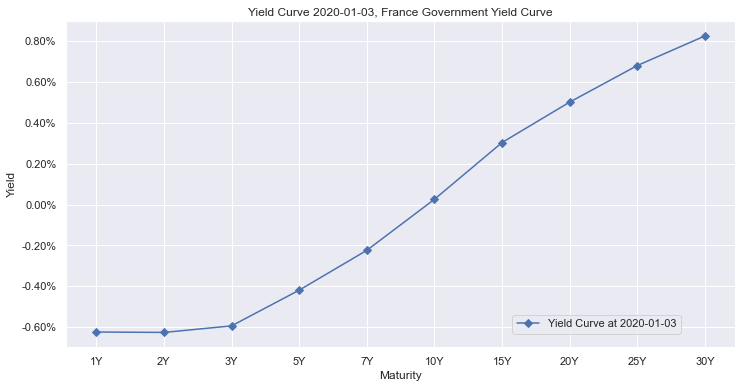

In [29]:
def plot_yield_curve(date, fig_n):
    maturities = ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y','15Y', '20Y', '25Y', '30Y'] # Maturities
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(maturities, yields.loc[date].to_numpy(), marker='D', label='Yield Curve at ' + date)

    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)

    # Add labels and title
    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title(fig_n+'France Government Yield Curve')


    fig.legend(loc = [0.69, 0.14])

    # Show the plot
    plt.grid(True)
    plt.show()

plot_yield_curve('2020-01-03','Yield Curve 2020-01-03, ')

#### c. Fit a Nelson-Siegel model. 

The **Nelson Siegel model (NS model)**  or **yield curve factor model** is a popular polynomial fitting model for describing the relationship between maturity and yield. Here is the formula for the model:

$$y(t)=\beta_{0}+\beta_{1}\left( \frac{1-e^{-\lambda t}}{\lambda t} \right)+\beta_{2}\left( \frac{1-e^{^{-\lambda t}}}{\lambda t}-e^{-\lambda t} \right)+\epsilon$$
<br>
where 
- $t$:  time to maturity
- 0 < $\lambda$ < 1: decay rate (speed to converge to the long-term average)
- $\beta_{0}$ : level of the yield curve
- $\beta_{1}$ : slope of the yield curve 
- $\beta_{2}$ : shape of the yield curve
<br>

Let's choose Yield Curves as of 2010-01-04 and 2020-01-03 to fit Nelson-Siegel model

In [30]:
# pip install nelson_siegel_svensson
# Import the packages
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
import numpy as np

In [31]:
# Fit an NS model for yields from 2020-01-03
# Create maturity and yield variables in array form
t = np.array([1,2,3,5,7,10,15,20,25, 30])
y = np.array(yields.loc["2020-01-03"])

curve, status = calibrate_ns_ols(t, y, tau0=1.0)  # starting value of 1.0 for the optimization of tau
assert status.success
print(curve)

NelsonSiegelCurve(beta0=1.322429628035892, beta1=-1.9398597701328533, beta2=-2.3208251164458784, tau=3.7402719164755664)


Text(0.5, 1.0, '2020-01-03, NS Model Result')

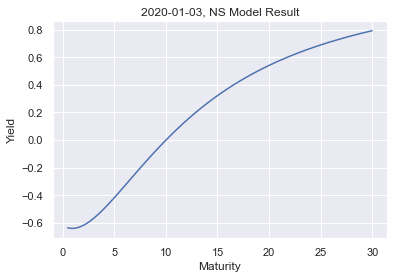

In [32]:
y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("2020-01-03, NS Model Result")

<ipython-input-29-ce42d634f70d>:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


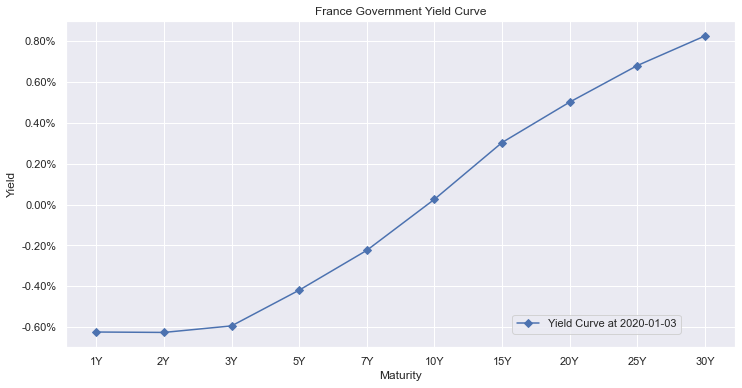

In [33]:
plot_yield_curve('2020-01-03','')

Text(0.5, 1.0, '2010-01-04, NS Model Result')

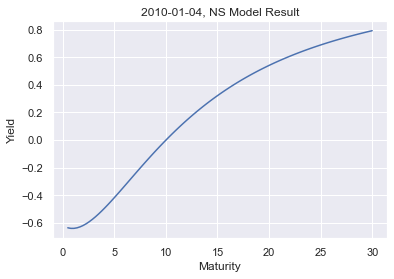

In [34]:
t = np.array([1,2,3,5,7,10,15,20,25, 30])
y = np.array(yields.loc["2020-01-03"])

y_hat = curve
t_hat = np.linspace(0.5,30,100)
plt.plot(t_hat, y_hat(t_hat))
plt.xlabel("Maturity")
plt.ylabel("Yield")
plt.title("2010-01-04, NS Model Result")

<ipython-input-29-ce42d634f70d>:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])


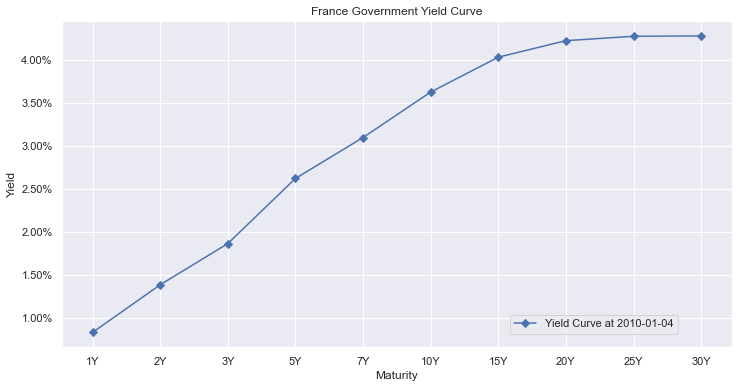

In [35]:
plot_yield_curve('2010-01-04','')

#### d. Fit a Cubic-Spline model.
I will go ahead and implement Cubic-Spline model for 2 yield curves as before for 2010-01-04 and 2020-01-03.
For that reason we need to construct the cubic sqpline equations. let's query the yield curve data, then we will calculate the coefficients. 

In [36]:
yields.loc["2010-01-04"]

1 Year     0.834
2 Year     1.387
3 Year     1.866
5 Year     2.622
7 Year     3.098
10 Year    3.626
15 Year    4.031
20 Year    4.223
25 Year    4.274
30 Year    4.278
Name: 2010-01-04 00:00:00, dtype: float64

In lecture notes it was manually calculated the coefficients, by creating cubic equations for each of the yield. 
We have 10 paired data points, there will be 9 splines equations, and 4*9 = 36 ceofficients to be calculated.
<br>
<br>
$$f\left( x \right)=a_{1}x^{3}+b_{1}x^{2}+c_{1}x+d_{1}, \text{when }1\le x\le 2$$
$$f\left( x \right)=a_{2}x^{3}+b_{2}x^{2}+c_{2}x+d_{2}, \text{when }2\le x\le 3$$
$$f\left( x \right)=a_{3}x^{3}+b_{3}x^{2}+c_{3}x+d_{3}, \text{when }3\le x\le 5$$
$$f\left( x \right)=a_{4}x^{3}+b_{4}x^{2}+c_{4}x+d_{1}, \text{when }5\le x\le 7$$
$$f\left( x \right)=a_{5}x^{3}+b_{5}x^{2}+c_{5}x+d_{2}, \text{when }7\le x\le 10$$
$$f\left( x \right)=a_{6}x^{3}+b_{6}x^{2}+c_{6}x+d_{3}, \text{when }10\le x\le 15$$
$$f\left( x \right)=a_{7}x^{3}+b_{7}x^{2}+c_{7}x+d_{1}, \text{when }15\le x\le 20$$
$$f\left( x \right)=a_{8}x^{3}+b_{8}x^{2}+c_{8}x+d_{2}, \text{when }20\le x\le 25$$
$$f\left( x \right)=a_{9}x^{3}+b_{9}x^{2}+c_{9}x+d_{3}, \text{when }25\le x\le 30$$

<br>
<br>

This eventually will result in 18 equations:

<br>
<br>
$$a_{1}(1)^{3}+b_{1}(1)^{2}+c_{1}(1)+d_{1}=0.834\;\;\;$$
$$a_{1}(2)^{3}+b_{1}(2)^{2}+c_{1}(2)+d_{1}=1.387\;\;\;$$

...

$$a_{9}(25)^{3}+b_{9}(25)^{2}+c_{9}(25)+d_{9}=4.274\;\;\;$$
$$a_{9}(30)^{3}+b_{9}(30)^{2}+c_{9}(30)+d_{9}=4.278\;\;\;$$
<br>
<br>

The first and second derivatives of two consecutive cubic splines being continuous at the common interior points, which will give us 2*8=16 equations:

$$3a_{1}(2)^{2}+2b_{1}(2)+c_{1}=3a_{2}(2)^{2}+2b_{2}(2)+c_{2}\;\;\;$$

..

$$3a_{8}(25)^{2}+2b_{8}(25)+c_{8}=3a_{9}(25)^{9}+2b_{9}(25)+c_{9}\;\;\;$$


$$6a_{1}(2)+2b_{1}=6a_{2}(2)+2b_{2}\;\;\;(9)$$

..

$$6a_{8}(25)+2b_{8}=6a_{9}(25)+2b_{9}\;\;\;(10)$$


The boundary conditions(the cubic splines at the end points to be zeroes) will give us 2 equations.
$$6a_{1}(1)+2b_{1}=0\;\;\;$$
$$6a_{9}(30)+2b_{9}=0\;\;\;$$

We could create the matrix and calculate it similar way as in lecture, but instead we will use already implemented CubicSpline from scipy.

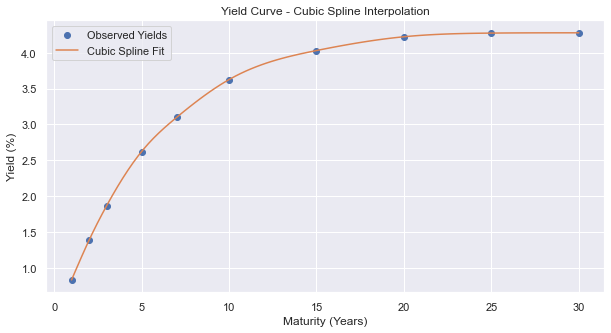

In [37]:
from scipy.interpolate import CubicSpline

# Maturities in years
x = np.array([1, 2, 3, 5, 7, 10, 15, 20, 25, 30])
# Corresponding yields for 2010-01-04
y = np.array([0.834, 1.387, 1.866, 2.622, 3.098, 3.626, 4.031, 4.223, 4.274, 4.278])

# Create cubic spline (natural boundary condition)
cs = CubicSpline(x, y, bc_type='natural')

# Evaluate spline at fine intervals (e.g., monthly maturities)
x_fine = np.linspace(1 ,30, 100)
y_fine = cs(x_fine)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'o', label='Observed Yields')
plt.plot(x_fine, y_fine, '-', label='Cubic Spline Fit')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.title('Yield Curve - Cubic Spline Interpolation')
plt.grid(True)
plt.legend()
plt.show()

In [38]:
yields.loc["2020-01-03"]

1 Year    -0.624
2 Year    -0.626
3 Year    -0.594
5 Year    -0.419
7 Year    -0.224
10 Year    0.026
15 Year    0.304
20 Year    0.502
25 Year    0.681
30 Year    0.826
Name: 2020-01-03 00:00:00, dtype: float64

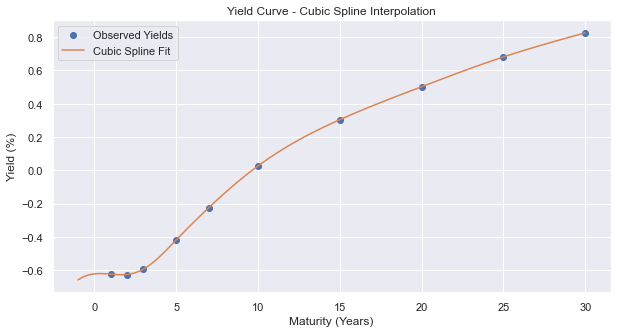

In [39]:
# Maturities in years
x = np.array([1, 2, 3, 5, 7, 10, 15, 20, 25, 30])
# Corresponding yields for 2020-01-03
y = np.array([    -0.624,-0.626,-0.594,-0.419,-0.224, 0.026, 0.304, 0.502, 0.681, 0.826])
cs = CubicSpline(x, y, bc_type='natural')

x_fine = np.linspace(-1 ,30, 100)
y_fine = cs(x_fine)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'o', label='Observed Yields')
plt.plot(x_fine, y_fine, '-', label='Cubic Spline Fit')
plt.xlabel('Maturity (Years)')
plt.ylabel('Yield (%)')
plt.title('Yield Curve - Cubic Spline Interpolation')
plt.grid(True)
plt.legend()
plt.show()

####  e. Compare the models in terms of 1) fit and 2) interpretation.
1) **Fit**:

The Nelson-Siegel model has a good and smooth fit to the yield curve with only four parameters. The advantage is that it uses only 4 parameters (level, slope, curvature and decay speed) to capture the shape of the yield curve.  

In contrast, Cubic-Spline model above fits data much more closely (especially at the sample points), but tend to produce poor out-of-sample performance (overfitting). The more sample points we supply, the more parameters will be required to estimate to fit the yield curve (in above example 10 yield point data increased number of parameters to 36), but the better the fit will be. However, this creates overfitting issue, where the model may not perform well on out of sample data. 


2) **Interpretation**:

Nelson-Siegel's parameters are more economically interpretable:
<br>
- $\beta_{0}$ represents the long-term rate (level).

- $\beta_{1}$ captures the short-term rate (slope).

- $\beta_{2}$ reflects medium-term curvature.

- 0 < $\lambda$ < 1: controls the location of the hump (decay speed).
<br>

Polynomial coefficients (e.g., $\alpha_{1}$, $\alpha_{2}, .. $, $\beta_{1}, ..$) lack direct economic meaning. They’re purely mathematical, making the Nelson-Siegel model better for interpretability, macro-financial applications and decision making.


####  f. Be sure to specify at the levels of model parameters (ex. Alpha1).

As mentioned in part e), in the Cubic-Spline model:

Parameters like $\alpha_{1}$, $\alpha_{2}, .. $, $\beta_{1}, ..$ define the intercept and slope(s) of the trend line but do not have any economic interpretation (e.g., short-term rates or yield curve shape).

Their values depend entirely on the dataset and provide no structural insights into the term structure of interest rates.

In contrast, in the Nelson-Siegel model:

<br>
- $\beta_{0}$ represents the long-term rate (level).

- $\beta_{1}$ captures the short-term rate (slope).

- $\beta_{2}$ reflects medium-term curvature.

- 0 < $\lambda$ < 1: controls the location of the hump (decay speed).
<br>


####  g. Is Nelson-Siegel smoothing the yield curve considered unethical? Why or why not?
Unethical smoothing refers to some kind of manipulation, for example, to hide risk, mislead stakeholders, fabricate trends… In Module 2, Lesson 4 unethical smoothing involves cases when smoothing is done on volatility (to increase Sharpe Ratio) and on PnL (to show less risky data). Both cases are misrepresentation of performance, and manipulation of data. Nelson-Siegel smoothing is not considered unethical. Nelson-Siegel is a replicable methodology and is based on economic theory. Its purpose is to summarize and understand the shape of the yield curve, not to manipulate or misrepresent data.

**References**
<br>
[1] Banque de France. (n.d.). Financial Markets – Webstat., https://webstat.banque-france.fr/en/catalogue/fm/.
<br>
